In [179]:
import numpy as np
import pandas as pd
import mne
import math
import os

In [248]:
# loading windows
base_dir = r"C:\Users\jshin\OW_closedloopLIFU\eeg_windows\scope\demo1119"
theta_df = []
csv_files = [f for f in os.listdir(base_dir) if f.endswith(".csv")]
csv_files.sort(key=lambda f: os.path.getctime(os.path.join(base_dir, f)))

for idx, window in enumerate(csv_files):
    path = os.path.join(base_dir, csv_files[idx])
    idx_df = pd.read_csv(path) 
    theta_df.append(idx_df)
theta_df[1]

,LSL Time,Raw,Theta Bandpass,Power,Moving Average,Z-score,Hold,Trigger Channel,offline z-score,median,mad,LIFU,t_rel,idx
0,555942.942283,41977.148438,2.100314,4.411321,1.399662,-0.220177,-0.241063,-0.042978,-0.241063,-0.019988,-0.241063,0.0,-1.990610,1
1,555942.948682,43096.355469,2.160960,4.669748,1.490604,-0.198420,-0.241063,-0.190241,-0.241063,-0.019988,-0.241063,0.0,-1.984211,1
2,555942.949231,43083.242188,2.185362,4.775806,1.581472,-0.176681,-0.241063,-0.289210,-0.241063,-0.019988,-0.241063,0.0,-1.983662,1
3,555942.951470,42019.156250,2.173498,4.724094,1.668627,-0.155831,-0.241063,-0.315746,-0.241063,-0.019988,-0.241063,0.0,-1.981423,1
4,555942.962679,41865.085938,2.126037,4.520034,1.748796,-0.136652,-0.241063,-0.271949,-0.241063,-0.019988,-0.241063,0.0,-1.970214,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1745,555949.920272,41690.667969,-0.710742,0.505154,0.319086,-0.478687,-0.460270,19.573053,-0.460270,-0.193197,-0.460270,0.0,4.987379,1
1746,555949.922850,42473.273438,-0.851733,0.725449,0.308784,-0.481152,-0.460270,-22.434015,-0.460270,-0.193197,-0.460270,0.0,4.989957,1
1747,555949.923838,43027.906250,-0.980726,0.961823,0.302390,-0.482682,-0.460270,-34.284973,-0.460270,-0.193197,-0.460270,0.0,4.990945,1
1748,555949.931260,42752.605469,-1.093329,1.195368,0.300696,-0.483087,-0.460270,1.483548,-0.460270,-0.193197,-0.460270,0.0,4.998367,1


In [233]:
#when it sonicates
lifu_markers = pd.read_csv("lifu_markers_1_2back_demo1119.csv")
lifu_on_df = lifu_markers[lifu_markers["marker"] == "LIFU_ON"]
lifu_on = np.array(lifu_on_df["LSL_timestamp"])
lifu_on

array([555924.8918494, 555944.9328929, 556030.6534903])

In [234]:
#finding baseline median and mean
medians = []
mads = []
tol = 0.002

for idx, event in enumerate(lifu_on):
    df = theta_df[idx]
    diff = np.abs(df["LSL Time"].values - event)
    i = np.argmin(diff)
    row = df.iloc[i]
    median = row["median"]
    mad = row["mad"]
    medians.append(median)
    mads.append(mad)
print(f"medians = {medians}")
print(f"mads = {mads}")

medians = [1.7600671648979187, -0.103686649352312, -0.0468030273914337]
mads = [1.6612875328788757, 0.3194501080939769, 1.7109483480453491]


In [247]:
# median percent change calculation
idx = 0
pre_sonication= []
post_sonication= []
percent_change_df = pd.DataFrame(lifu_on, columns=["Time"])

#for loop
for idx, event in enumerate(lifu_on):
    df = theta_df[idx]
    pre_df = df[df["LSL Time"]<= event]
    pre_mean = np.mean(np.array(pre_df["Hold"].dropna()))
    post_df = df[df["LSL Time"]>= event]
    post_mean = np.mean(np.array(post_df["Hold"].dropna()))
    pre_sonication.append(pre_mean)
    post_sonication.append(post_mean)
percent_change_df["pre average median"] = pre_sonication
percent_change_df["post average median"] = post_sonication
# CHECK IF EQUATION IS CORRECT -- also slope
percent_change_df["percent change %"] = 100* (percent_change_df["post average median"] - percent_change_df["pre average median"])/ percent_change_df["pre average median"]
percent_change_df

,Time,pre average median,post average median,percent change %
0,555924.891849,6.129165,0.556854,-90.914689
1,555944.932893,0.171976,0.066313,-61.440616
2,556030.653490,0.712175,0.666865,-6.362147


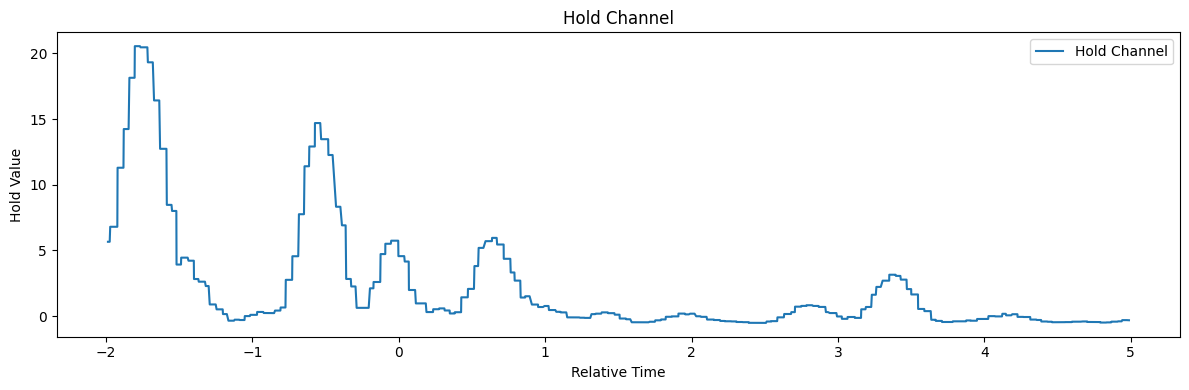

In [246]:
# plot thetas
import matplotlib.pyplot as plt

df = theta_df[0]


plt.figure(figsize=(12,4))
plt.plot(df["t_rel"], df["Hold"], label="Hold Channel")
plt.xlabel("Relative Time")
plt.ylabel("Hold Value")
plt.title("Hold Channel")
plt.legend()
plt.tight_layout()
plt.show()